# Proyecto Deep Learning Spotify: Tarea 2 - Modelo Machine Learning

## Configuración del entorno

In [ ]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

sys.path.append(os.path.abspath('..'))
from models.red_neuronal import crear_red_simple

In [2]:
df = pd.read_csv(r'..\data\data.csv')

df_limpio = df[
    (df['duration_ms'] > 40000) & 
    (df['speechiness'] < 0.90) & 
    (df['tempo'] > 0)
].copy()

cols_to_drop = ['popularity', 'id', 'name', 'artists', 'id_artists', 'release_date', 'mode']
X = df_limpio.drop(columns=cols_to_drop, errors='ignore')
y = df_limpio['popularity']

In [3]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [4]:
modelo_nn = crear_red_simple(X_train_scaled.shape[1])

print("RESUMEN DE LA ARQUITECTURA (NÚMERO DE PARÁMETROS)")
modelo_nn.summary()

historia = modelo_nn.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=256,
    verbose=1
)

RESUMEN DE LA ARQUITECTURA (NÚMERO DE PARÁMETROS)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61 (244.00 B)

 Trainable params: 61 (244.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1457.8618 - mae: 31.7811 - val_loss: 1316.8774 - val_mae: 30.0471
Epoch 2/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1175.1223 - mae: 28.3909 - val_loss: 998.8884 - val_mae: 26.0251
Epoch 3/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 855.1451 - mae: 23.7740 - val_loss: 707.3585 - val_mae: 21.1668
Epoch 4/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 619.9667 - mae: 19.3398 - val_loss: 536.9568 - val_mae: 17.5447
Epoch 5/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 498.6104 - mae: 16.6894 - val_loss: 458.0151 - val_mae: 15.8098
Epoch 6/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 439.2991 - mae: 15.4194 - val_loss: 413.8659 - val_mae: 14.9048
Epoch 7/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 399.4789 - mae: 14.6030 - val_loss: 376.9828 - val_mae: 14.1376
Epoch 8/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 361.4451 - mae: 13.7932 - val_loss: 339.0750 - val_mae: 13.3014
Epoch

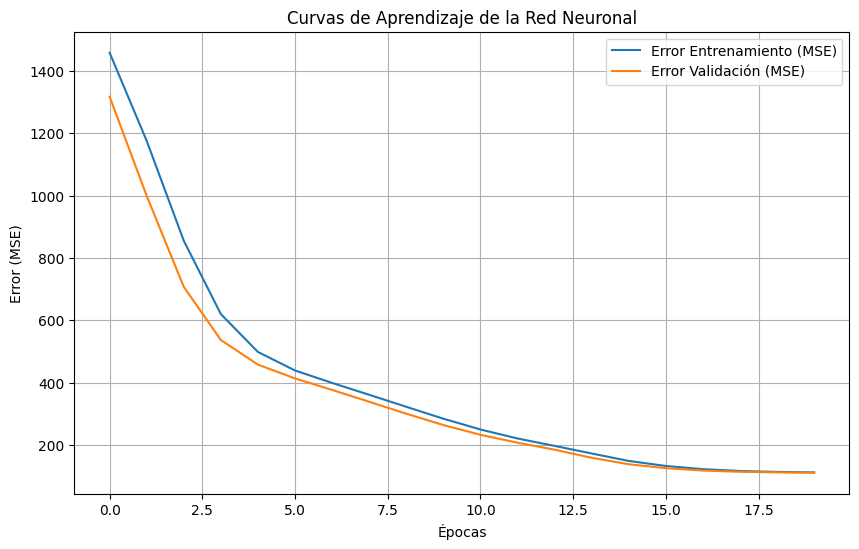

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(historia.history['loss'], label='Error Entrenamiento (MSE)')
plt.plot(historia.history['val_loss'], label='Error Validación (MSE)')
plt.title('Curvas de Aprendizaje de la Red Neuronal')
plt.xlabel('Épocas')
plt.ylabel('Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
def evaluar_red(modelo, X_data, y_true, nombre_conjunto):
    y_pred = modelo.predict(X_data, verbose=0).flatten()
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- Resultados en {nombre_conjunto} ---")
    print(f"MSE:  {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²:   {r2:.4f}\n")

print("EVALUACIÓN RED NEURONAL\n")

evaluar_red(modelo_nn, X_train_scaled, y_train, "ENTRENAMIENTO")
evaluar_red(modelo_nn, X_val_scaled, y_val, "VALIDACIÓN")
evaluar_red(modelo_nn, X_test_scaled, y_test, "TEST")

EVALUACIÓN RED NEURONAL

--- Resultados en ENTRENAMIENTO ---
MSE:  112.11
RMSE: 10.59
R²:   0.7591

--- Resultados en VALIDACIÓN ---
MSE:  111.60
RMSE: 10.56
R²:   0.7611

--- Resultados en TEST ---
MSE:  107.44
RMSE: 10.37
R²:   0.7668

